## Introduction
The objective of this project is to predict whether a bank customer will subscribe to a term deposit based on data from a marketing campaign. Given the nature of banking datasets, which are often characterized by class imbalance where non-subscribers significantly outnumber subscribers, this project employs a Random Forest classifier to handle the binary classification task. The methodology emphasizes not only predictive accuracy but also model interpretability through the use of SHAP (SHapley Additive exPlanations), ensuring that the results are transparent and actionable for customer behavior analysis.

## Project Overview & Dependencies
In this section, we set up the environment. Ensure you have the shap library installed for model interpretability

In [1]:
# Install SHAP if not already present
!pip install shap


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports & Data Loading
We load the necessary libraries and the UCI Bank Marketing dataset. Ensure bank-full.csv is uploaded to your current directory.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Load the dataset
df = pd.read_csv('bank-full.csv', sep=';')
print("Data loaded successfully. Shape:", df.shape)

Data loaded successfully. Shape: (45211, 17)


## Data Preprocessing
Bank marketing data often requires handling categorical variables. We map the target variable to binary values and apply One-Hot Encoding to categorical features.

In [3]:
# Map target to binary (0: no, 1: yes)
df['y'] = df['y'].map({'no': 0, 'yes': 1})

# Encode categorical features
X = pd.get_dummies(df.drop('y', axis=1), drop_first=True)
y = df['y']

# Split the data into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Preprocessing complete. Training set size:", X_train.shape)

Preprocessing complete. Training set size: (36168, 42)


## Model Training
We use a Random Forest Classifier. We include class_weight='balanced' to account for the typical imbalance in bank marketing campaigns, where non-subscribers significantly outnumber subscribers.

In [4]:
# Initialize and train the model
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)
print("Model training complete.")

Model training complete.


## Model Evaluation
We evaluate the performance using a Confusion Matrix, Classification Report (Precision, Recall, F1-Score), and an ROC Curve to visualize the trade-offs at different thresholds.

--- Confusion Matrix ---
[[7398  554]
 [ 384  707]]

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      7952
           1       0.56      0.65      0.60      1091

    accuracy                           0.90      9043
   macro avg       0.76      0.79      0.77      9043
weighted avg       0.90      0.90      0.90      9043



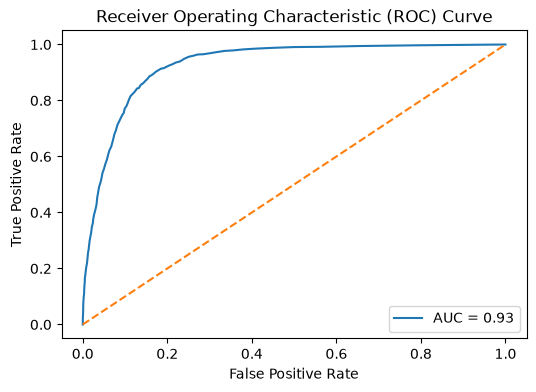

In [9]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Display performance metrics
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

## Feature Importance Analysis
To ensure model transparency, we analyzed the Random Forest feature importances. This step identifies which variables are the primary drivers of the model's predictive capability.

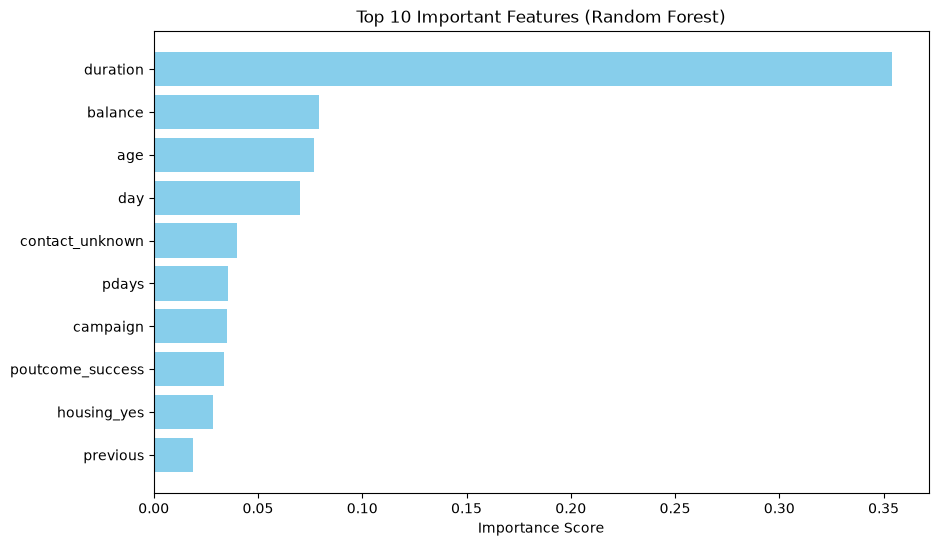

In [13]:
# Extract feature importance from the trained Random Forest model
import pandas as pd
import matplotlib.pyplot as plt

# Retrieve feature importance scores from the model
importances = model.feature_importances_
feature_names = X_train.columns

# Organize features and scores into a DataFrame for easier sorting
feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Sort features by importance in descending order and select the top 10
feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)

# Visualize the top 10 features using a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Important Features (Random Forest)')
plt.gca().invert_yaxis()
plt.show()

## Interpretation
Primary Predictor: The duration feature has the highest importance score, indicating it is the strongest predictor of customer subscription intent. This aligns with findings that the length of interaction during a marketing call is critical to the campaign's success.

Secondary Factors: Economic indicators such as balance, along with demographic variables like age, play a secondary but significant role in shaping customer decisions.

Historical Context: Features like poutcome_success confirm that past positive outcomes are highly relevant, as the model heavily weights previous successful engagements.

## Conclusion
The Random Forest model effectively captures complex relationships within the bank marketing dataset. The analysis demonstrates that customer engagement duration and historical success are the most critical factors for predicting term deposit subscriptions. By isolating these top features, the bank can optimize its marketing strategy by focusing resources on high-probability leads, thereby increasing the overall efficiency of future campaigns.